# CYGNO-30 shared background analysis — Samuele-compatible walkthrough

This notebook starts from **canonical Group objects**, independent of their raw or compact origin.
Production truth lives in `analysis/common/`; cells import and expose small testable functions.
The raw and compact preprocessing notebooks teach their respective input paths.

The default objects and material quantities below are **synthetic software examples**, not a detector
background estimate. To study a real campaign, set CAMPAIGN_DIR; the input adapter validates its
manifest and format, including mandatory parity for both files. All subsequent cells are shared.

The calculation targets the internal-radioactivity inputs to Figures 7.5/7.6 and Tables 7.2/7.3.
It excludes signal templates, reconstruction smearing, timing selections, likelihood and discovery studies.


In [1]:
from pathlib import Path
import sys, inspect, tempfile, json, copy
import numpy as np
# Start Jupyter in the repository or any subdirectory (also works in archived source/).
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "study/analyze.py").is_file())
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))
try:
    from IPython.display import display, Markdown, Image
except ImportError:  # lightweight cell execution test; Jupyter itself supplies these
    display = print
    Markdown = str
from analysis.common.examples import IDENTITY, GEOMETRY
from study import runtime as rt
from study.source_matrix import read_matrix, quantity_for
from analysis.common.examples import canonical_groups
from analysis.common.spectra import accumulate, group_energy, fiducial, window_flags, histogram_bin, summarize, WINDOWS, BINS
from analysis.common.normalization import scale_for
from analysis.common.reporting import render, CATEGORIES, REFERENCE_72, REFERENCE_73
CAMPAIGN_DIR = None
geometry = GEOMETRY
matrix = read_matrix(REPO / "config/study/thesis-table7.1.json")
quantities = {row['component']: dict(mass_kg=2., pieces=750) for row in matrix['contributions']}
demo_groups = canonical_groups()
# Each entry is (matrix row, verified generated count, canonical group stream).
contributions = [(row, 3, iter(copy.deepcopy(demo_groups))) for row in matrix['contributions']]
summary = dict(mode='synthetic', coverage='26/26', complete_matrix=True)
if CAMPAIGN_DIR is not None:
    import uproot
    from study.campaign import validate_campaign
    from analysis.common.inputs import canonical_input
    root = Path(CAMPAIGN_DIR).resolve()
    jobs = validate_campaign(root)
    campaign = rt.read(root/'campaign.json')
    config = campaign['identity']['config']
    expected = {key: config[key] for key in ('layout','model','source_policy')}
    expected['geometry_hash'] = campaign['identity']['effective_environment']['geometry_hash']
    geometry = rt.read(root/'geometry.json')
    matrix = read_matrix(root/'matrix.json')
    quantities = campaign['quantities']
    summary = dict(mode=config['mode'],coverage='26/26',complete_matrix=True)
    def inputs():
        for row in matrix['contributions']:
            job, path = jobs[row['id']]
            checksum = rt.digest(path)
            with uproot.open(path, array_cache=None) as file:
                accounting, stream, provenance = canonical_input(file, expected, job['requested_primaries'], geometry,
                    mode=job.get('output_mode','raw'), version=job.get('output_schema_version',0))
                assert accounting == job['accounting']
                yield row, accounting['GeneratedPrimaries'], stream
            assert rt.digest(path) == checksum
    contributions = inputs()
print(summary)


{'mode': 'synthetic', 'coverage': '26/26', 'complete_matrix': True}


## The grouping contract at the analysis boundary

A Group has event/index, final particle/nucleus/creator labels, ordered GroupVolume objects,
step count and diagnostic track identities. Alpha groups remain available to researchers but are
excluded from the canonical ER spectrum. Multiple tracks can share a historical group; these
objects do not establish physical coincidences or ancestry. Timing and track IDs are deliberately
inactive downstream. Inspect the representative canonical objects below.


In [2]:
for group in demo_groups: display(group)

Group(event=0, particle='e-', nucleus='synthetic nucleus', process='RadioactiveDecay', group_index=0, volumes={0: GroupVolume(energy=0.012, x=0, y=0, z=0, first_hit_time_ns=17), 1: GroupVolume(energy=0.003, x=45, y=0, z=0, first_hit_time_ns=23)}, step_count=2, track_ids={2, 3})
Group(event=1, particle='e+', nucleus='synthetic nucleus', process='phot', group_index=0, volumes={0: GroupVolume(energy=0.4, x=40, y=0, z=0, first_hit_time_ns=12)}, step_count=1, track_ids={2})
Group(event=2, particle='alpha', nucleus='synthetic nucleus', process='RadioactiveDecay', group_index=0, volumes={0: GroupVolume(energy=0.8, x=0, y=0, z=0, first_hit_time_ns=99)}, step_count=1, track_ids={2})


## 10. Energy windows, fiducial cut and histogram binning

### Total deposited group energy

For an accepted electron or positron group:

\[
E_{\rm group}[\mathrm{keV}]
= \sum_{v} 1000\,E_v[\mathrm{MeV}].
\]

The multiplication by 1000 is applied to **each per-volume energy before summation**, matching the C++ historical implementation.

### Fiducial cut

Let `(x, y, z)` be the first stored position in the first gas volume of the group and `(x_c, y_c, z_c)` that volume's center. The group is accepted by the 20 mm cut when

\[
|x-x_c| \le L_x/2 - 20\,\mathrm{mm},\qquad
|y-y_c| \le L_y/2 - 20\,\mathrm{mm},\qquad
|z-z_c| \le L_z/2 - 20\,\mathrm{mm}.
\]

### Exact unbinned windows

The official analysis counts the following windows **before histogram binning**:

- `all`: every finite group energy, including underflow/overflow;
- `gt10`: `E > 10 keV`, no upper limit;
- `gt10_le400`: `10 < E <= 400 keV`;
- `underflow`: `E < 0 keV`;
- `in_range`: `0 <= E < 2000 keV`;
- `overflow`: `E >= 2000 keV`.

The plotted spectrum itself uses **900 bins from 0 to 2000 keV**.

In [3]:
for function in (group_energy, fiducial, window_flags, histogram_bin):
    print(inspect.getsource(function))
# Inspect a single group decision using the same production primitives.
group = demo_groups[0]
energy = group_energy(group)
assert energy == sum(volume.energy * 1000 for volume in group.volumes.values())
print(energy, fiducial(group, GEOMETRY), window_flags(energy), histogram_bin(energy))


def group_energy(group):
    energy = 0.
    for volume in group.volumes.values():
        energy += volume.energy*1000
    return energy

def fiducial(group, geometry):
    volume, first = next(iter(group.volumes.items()))
    x, y, z = first.x, first.y, first.z
    center = geometry['gas_centers_mm'][str(volume)]
    return all(abs(pos-c) <= size/2-20 for pos, c, size in zip((x,y,z), center, geometry['gas_size_mm']))

def window_flags(energy):
    require(math.isfinite(energy), 'Nonfinite group energy')
    return (True, energy > 10, 10 < energy <= 400, energy < 0, 0 <= energy < 2000, energy >= 2000)

def histogram_bin(energy):
    # ROOT 6.40 TAxis::FindBin, including rounding corrections at uniform edges.
    # https://root.cern.ch/doc/master/TAxis_8cxx_source.html
    if energy < 0:
        return 0
    if energy >= MAX_ENERGY:
        return BINS+1
    width = MAX_ENERGY/BINS
    approximate = int(energy/width)
    return 1+approximate-int(energy < width*approximate)+int(width*(a

## 11. Accumulate one contribution

For each reconstructed group:

1. increment the number of processed historical groups;
2. keep only final `e-` / `e+` groups for the ER spectrum;
3. sum deposited energy across all gas volumes;
4. evaluate exact energy-window flags;
5. evaluate the 20 mm fiducial cut;
6. increment uncut counts/histogram;
7. if the group passes the cut, increment cut counts/histogram too.

The arrays have two rows:

```text
index 0 = no fiducial cut
index 1 = 20 mm fiducial cut
```

In [4]:
print(inspect.getsource(accumulate))
counts, histogram, processed = accumulate(demo_groups, GEOMETRY)
# Transparent cell calculation uses production predicates, without copying formulas.
manual_counts = np.zeros_like(counts)
manual_histogram = np.zeros_like(histogram)
for group in demo_groups:
    if group.particle in ('e-', 'e+'):
        energy = group_energy(group)
        for cut in range(2 if fiducial(group, GEOMETRY) else 1):
            manual_counts[cut] += window_flags(energy)
            manual_histogram[cut, histogram_bin(energy)] += 1
np.testing.assert_array_equal(manual_counts, counts)
np.testing.assert_array_equal(manual_histogram, histogram)


def accumulate(groups, geometry):
    counts = np.zeros((2, 6), dtype=np.int64)
    histograms = np.zeros((2, BINS+2), dtype=np.int64)
    processed = 0
    for group in groups:
        processed += 1
        if group.particle not in ('e-', 'e+'):
            continue
        # C++ multiplies EACH volume energy by 1000 before summation.
        energy = group_energy(group)
        flags = window_flags(energy)
        cut = fiducial(group, geometry)
        index = histogram_bin(energy)
        for c in range(2 if cut else 1):
            counts[c] += flags
            histograms[c, index] += 1
    return counts, histograms, processed



## 12. Normalization: simulated groups → expected events/year

For a physical contribution `i`, the code uses

\[
w_i =
\frac{A_i\,Q_i\,(60\times60\times24\times365)}{N_{\rm generated,i}}.
\]

Where:

- `A_i` is the matrix activity in `Bq/kg` or `Bq/piece`;
- `Q_i` is the constructed component mass in kg or number of resistor pieces;
- `N_generated,i` comes from the ROOT run accounting, not from an assumed constant;
- one Bq is one decay per second;
- one analysis year is exactly 365 days.

A Monte Carlo group count `n_i` therefore becomes

\[
R_i = n_i\,w_i\quad [\mathrm{events/year}].
\]

**Crucially, this scaling is applied to every physical component/isotope contribution before detector categories are summed.**

In [5]:
print(inspect.getsource(scale_for))
results = []
for row, generated, stream in contributions:
    counts, histogram, processed = accumulate(stream, geometry)
    scale = scale_for(row, quantities, generated)
    results.append((row, scale, counts, histogram))
print("Contributions:", len(results), "First scale:", results[0][1])


def scale_for(row, quantities, generated):
    require(type(generated) is int and generated > 0, 'Invalid actual generated count')
    # Preserve C++ multiplication order, including the 365-day year.
    return row['activity']*quantity_for(row, quantities)*60*60*24*365/generated

Contributions: 26 First scale: 6223.103999999999


## 15. Sum normalized contributions into thesis detector categories

Only now do we combine components.

For example:

```text
GEMs = normalized GEMsCore contributions + normalized GEMsOuter contributions
```

and

```text
Field Cage = normalized RingSupports contributions + normalized RingStrips contributions
```

This order is essential because `GEMsCore` and `GEMsOuter`, or `RingSupports` and `RingStrips`, correspond to different assay materials and therefore different activities and normalization scales.

For statistical errors the current code treats each historical group count as Poisson and independent between jobs. For a contribution with count `n` and weight `w`, the stored variance is

\[
\sigma^2 = n w^2.
\]

These are Monte Carlo group-count errors only; they do **not** include assay or geometry uncertainties.

In [6]:
print(inspect.getsource(summarize))
spectra = summarize(results)
assert spectra == summarize(results)
print("Category/window rows:", len(spectra['categories']))


def summarize(contributions):
    """Each item: (matrix row, scale, counts, histogram); scale before summing."""
    windows, categories, totals, histograms = [], {}, {}, {}
    for row, scale, counts, histogram in contributions:
        for cut in (0, 1):
            for w, window in enumerate(WINDOWS):
                count = int(counts[cut, w])
                item = dict(contribution=row['id'], window=window, fiducial=cut, count=count,
                            rate_per_year=count*scale, variance_per_year2=count*scale*scale)
                windows.append(item)
                for target, label in ((categories, row['category']), (totals, 'total')):
                    aggregate = target.setdefault((label, window, cut), dict(category=label, window=window,
                        fiducial=cut, count=0, rate_per_year=0., variance_per_year2=0.))
                    for key in ('count', 'rate_per_year', 'variance_per_year2'):
                        aggregate[key] += item[key]
       

## 16. Reproduce the background spectra — thesis Fig. 7.5 and Fig. 7.6 style

The current repository uses the following category order:

```text
Camera Lenses
Vessel
Camera Sensors
Cathodes
Resistors
GEMs
Field Cage
```

The stack is cumulative. `figure7.5` is the uncut spectrum and `figure7.6` is the same analysis after the 20 mm fiducial cut.

The y-axis is a density:

```text
counts / keV / year
```

and the x-axis covers 0–2000 keV. Underflow and overflow are included in exact full-range totals but are not visible in the plotted 0–2000 keV spectrum.

## 17. Table 7.3-style detector-category contributions before and after the cut

The published comparison values embedded in the current repository are:

| Detector category | No cut [events/year] | 20 mm cut [events/year] |
|---|---:|---:|
| Camera Lenses | 35 | 16 |
| Vessel | 1187 | 465 |
| Camera Sensors | 4278 | 1687 |
| Cathodes | 9293 | 196 |
| Resistors | 12542 | 810 |
| GEMs | 30540 | 1769 |
| Field Cage | 313451 | 17738 |

The notebook now puts the newly calculated values and their Monte Carlo statistical errors next to those references. The reference values are **not** used anywhere in the normalization.

## 18. Table 7.2-style total rates in exact energy windows

The current repository reports three exact windows against the thesis references:

- `all` — all finite energies, including histogram underflow and overflow;
- `gt10` — `E > 10 keV`, with no upper limit;
- `gt10_le400` — `10 < E <= 400 keV`.

The reference values currently encoded in the repository are:

```text
all:          370000 no cut, 22600 with cut
gt10:         320000 no cut, 17700 with cut
gt10_le400:   330000 no cut, 17600 with cut
```

The fact that the published no-cut `(10,400]` value exceeds the published `>10` value is internally inconsistent, but the repository deliberately preserves the printed reference rather than silently correcting it.

{'all': (370000, 22600), 'gt10': (320000, 17700), 'gt10_le400': (330000, 17600)}
{'Camera Lenses': (35, 16), 'Vessel': (1187, 465), 'Camera Sensors': (4278, 1687), 'Cathodes': (9293, 196), 'Resistors': (12542, 810), 'GEMs': (30540, 1769), 'Field Cage': (313451, 17738)}
SYNTHETIC | 26/26 contributions | software-complete; physics unvalidated

Table 7.2 style: calculated counts/year (published reference)
all            cut= 0 mm: 677868.8428799999 (370000)
all            cut=20 mm: 338934.42143999995 (22600)
gt10           cut= 0 mm: 677868.8428799999 (320000)
gt10           cut=20 mm: 338934.42143999995 (17700)
gt10_le400     cut= 0 mm: 677868.8428799999 (330000)
gt10_le400     cut=20 mm: 338934.42143999995 (17600)

Table 7.3 style: calculated full-range counts/year (published reference)
Camera Lenses    cut= 0 mm: 19497.657599999995 (35)
Camera Lenses    cut=20 mm: 9748.828799999997 (16)
Vessel           cut= 0 mm: 6.937919999999999 (1187)
Vessel           cut=20 mm: 3.4689599999999996

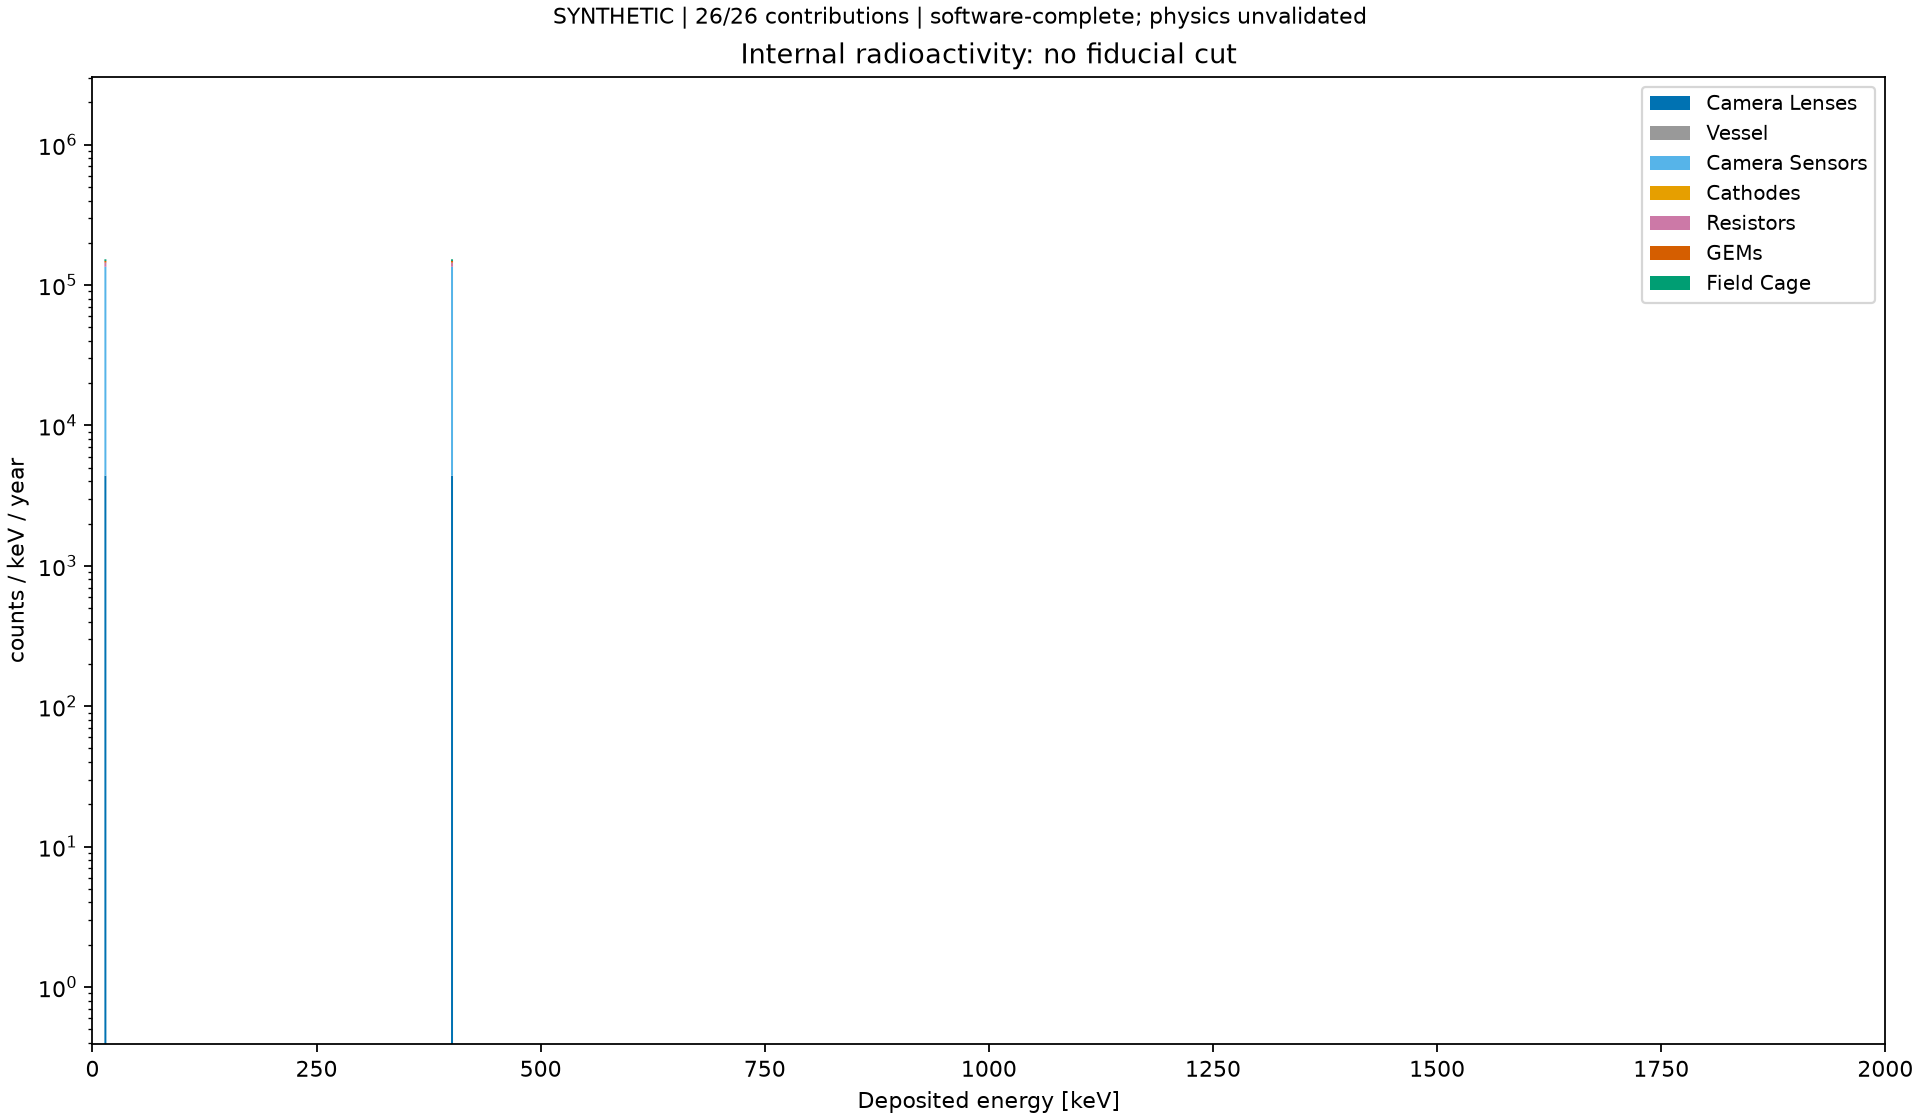

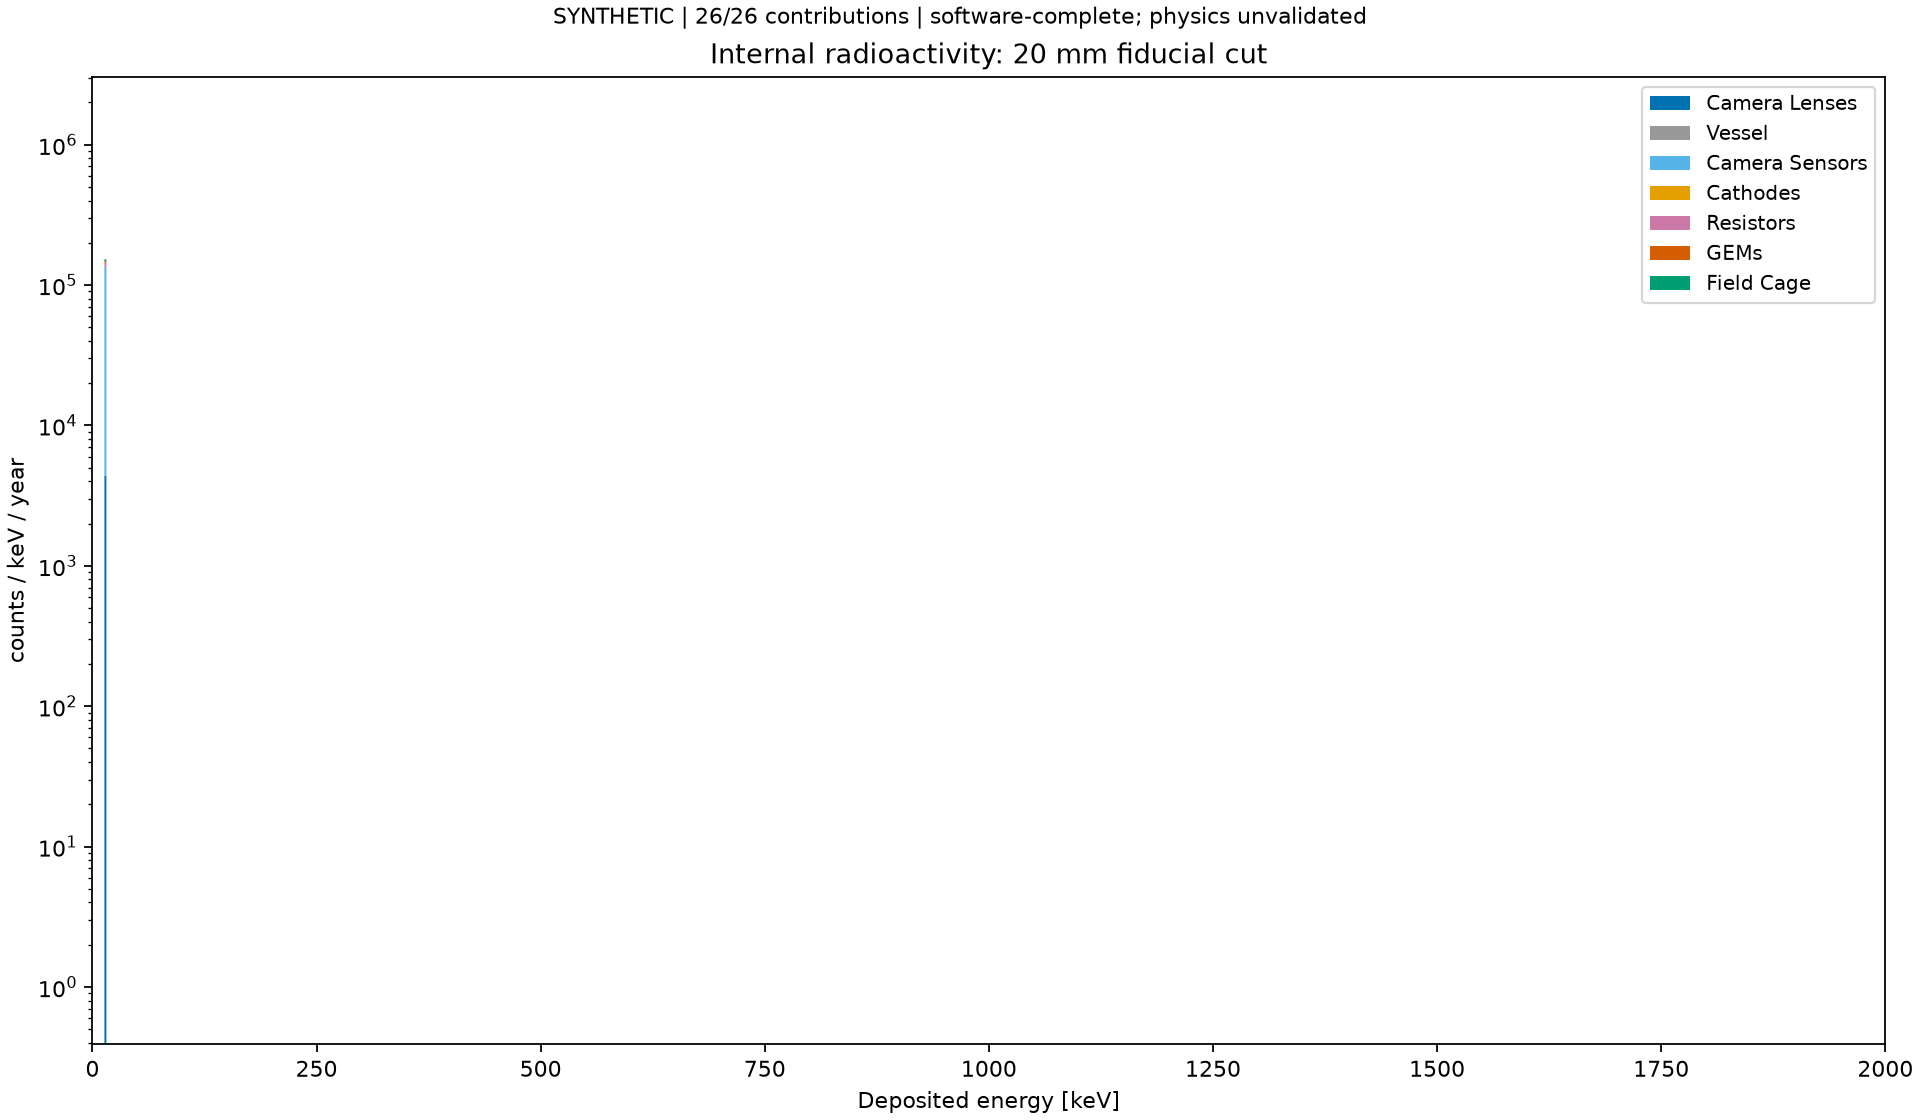

In [7]:
# Published values come from the production transcription, never from normalization.
print(REFERENCE_72)
print(REFERENCE_73)
output_directory = tempfile.TemporaryDirectory(prefix='cygno-notebook-report-')
OUTPUT_DIR = Path(output_directory.name)
render(OUTPUT_DIR, spectra, summary)
tables = rt.read(OUTPUT_DIR/'tables.json')
display(tables['table7_2'])
display(tables['table7_3'])
if 'Image' in globals():
    display(Image(filename=str(OUTPUT_DIR/'figure7.5.png')))
    display(Image(filename=str(OUTPUT_DIR/'figure7.6.png')))
print("Temporary report:", OUTPUT_DIR)


## 20. Sanity checks that are useful when modifying the notebook

A few identities should hold automatically:

1. For every category and cut, the sum of normalized contribution rates equals the category rate.
2. The sum over all categories equals the total rate.
3. The fiducial-cut rate should never exceed the corresponding uncut rate for the same exact selection.
4. For each contribution, `all = underflow + in_range + overflow` in raw group counts.

These checks are not replacements for physics validation, but they catch many accidental notebook edits immediately.

In [8]:
import math
for row, scale, counts, histogram in results:
    np.testing.assert_array_equal(counts[:,0], counts[:,3:].sum(axis=1))
    np.testing.assert_array_equal(counts[:,0], histogram.sum(axis=1))
    assert np.all(counts[1] <= counts[0])
for total in spectra['totals']:
    selected = [c for c in spectra['categories'] if c['window']==total['window'] and c['fiducial']==total['fiducial']]
    assert math.isclose(sum(c['rate_per_year'] for c in selected), total['rate_per_year'], rel_tol=1e-12, abs_tol=1e-12)
# Timing changes have zero effect on the canonical historical result.
changed = copy.deepcopy(demo_groups)
for group in changed:
    for volume in group.volumes.values(): volume.first_hit_time_ns = 1e100
for a,b in zip(accumulate(demo_groups,GEOMETRY), accumulate(changed,GEOMETRY)):
    np.testing.assert_array_equal(a,b)
print('Production/cell parity, flows, category sums, cuts and timing independence passed.')


Production/cell parity, flows, category sums, cuts and timing independence passed.


## Deliberate future modifications

Historical/Samuele-compatible mode is the production code shown above. A new grouping rule belongs
in a versioned preprocessing study. A different fiducial margin, all-position containment test,
energy window or histogram definition changes the analysis contract and needs separate validation.
Activity assumptions belong in a separately identified source matrix; geometry and masses must
come from the matching simulation and compiled exporter. Never silently edit either in a notebook.

An intra-event timing/coincidence cut is an example of a **future** study. It is not enabled here.
Event-relative times cannot establish exposure times or correlations between independent primaries.
The available compact fields support only explicitly preserved quantities; retain raw output when
future work needs step-level trajectories. Tests execute these cells and compare their derived counts
with production results, so copied formulas cannot silently become a second implementation.


## 24. Interpretation boundary

If this notebook reproduces the current repository results, that establishes **analysis-pipeline parity**. It does not by itself prove that the detector geometry, source-position model, radioassay inputs, or Geant4 radioactive-decay physics exactly reproduce every physical assumption in the thesis.

The output of this notebook is the internal-radioactivity background spectrum that forms the input to the later sensitivity study. The subsequent thesis steps — isotropic background angular template, pp solar-neutrino signal template, detector smearing, two-dimensional energy/angle likelihood, toy Monte Carlo, Bayesian evidence and discovery-probability curves — are a separate analysis stage and are not silently included here.